<a href="https://colab.research.google.com/github/dineshdabbera/FUTURE_ML_02/blob/main/Support_Ticket_Classification_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

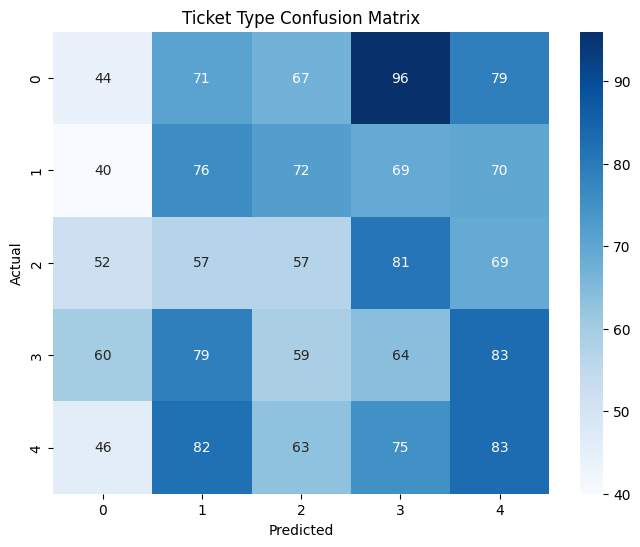

Predicted Ticket Type: Product inquiry
Predicted Priority: Medium


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import joblib

nltk.download('stopwords')
df = pd.read_csv('customer_support_tickets.csv')

print(df.head())
print(df.columns)
print(df.shape)
df['text'] = df['Ticket Subject'].astype(str) + ' ' + df['Ticket Description'].astype(str)
df = df.dropna(subset=['Ticket Type', 'Ticket Priority'])
top_words = set(stopwords.words('english'))


def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [word for word in words if word not in top_words]
    return ' '.join(words)


df['clean_text'] = df['text'].apply(clean_text)
X = df['clean_text']

y_type = df['Ticket Type']
y_priority = df['Ticket Priority']

vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y_type,
    test_size=0.2,
    random_state=42
)

model_type = LogisticRegression(max_iter=1000)
model_type.fit(X_train, y_train)

y_pred = model_type.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_vectorized,
    y_priority,
    test_size=0.2,
    random_state=42
)

model_priority = LogisticRegression(max_iter=1000)
model_priority.fit(X_train_p, y_train_p)

y_pred_p = model_priority.predict(X_test_p)

print('Priority Accuracy:', accuracy_score(y_test_p, y_pred_p))
print(classification_report(y_test_p, y_pred_p))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Ticket Type Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
joblib.dump(model_type, 'ticket_type_model.pkl')
joblib.dump(model_priority, 'priority_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
sample_ticket = 'Unable to access my account and payment failed.'

sample_clean = clean_text(sample_ticket)
sample_vector = vectorizer.transform([sample_clean])

predicted_type = model_type.predict(sample_vector)
predicted_priority = model_priority.predict(sample_vector)

print('Predicted Ticket Type:', predicted_type[0])
print('Predicted Priority:', predicted_priority[0])